In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

###  Load the Cleaned Data

In [24]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
print('Data Shape:', df.shape)
df.head()

Data Shape: (32409, 12)


,age,income,home_ownership,employment_years,loan_purpose,loan_grade,loan_amount,interest_rate,default,loan_income_ratio,previous_default,credit_history_years
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


###  Loan Default Distribution (Target Variable)

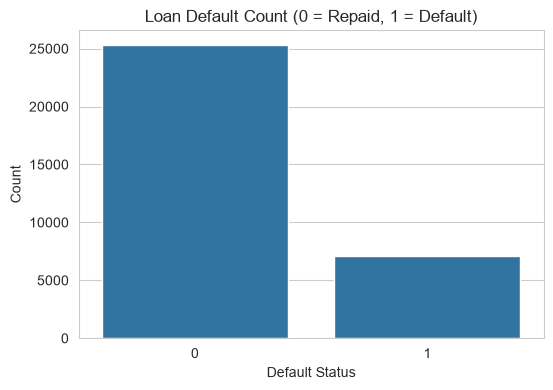

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='default')
plt.title('Loan Default Count (0 = Repaid, 1 = Default)')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.show()

###  Default vs Non-Default Percentage (Pie Chart)

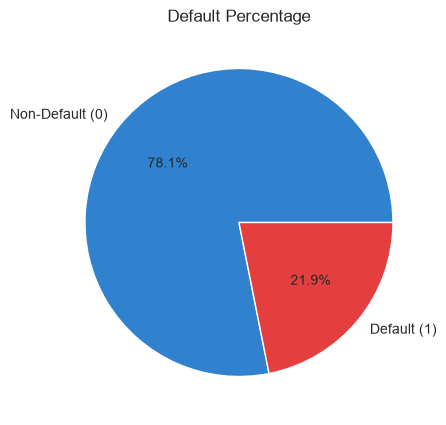

In [26]:
plt.figure(figsize=(5, 5))
df['default'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Non-Default (0)', 'Default (1)'],
    colors=['#3182CE', '#E53E3E']
)
plt.title('Default Percentage')
plt.ylabel('')
plt.show()

###  Loan Grade vs Default

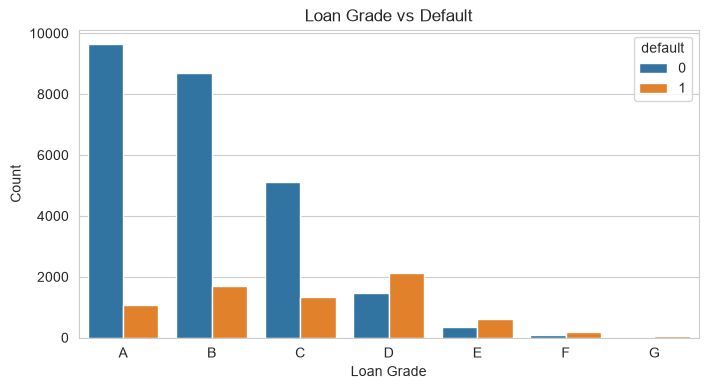

In [27]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='loan_grade', hue='default', order=sorted(df['loan_grade'].unique()))
plt.title('Loan Grade vs Default')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.show()

###  Home Ownership vs Default

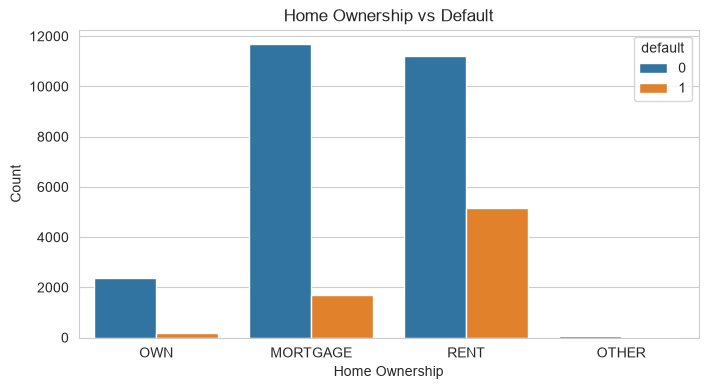

In [28]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='home_ownership', hue='default')
plt.title('Home Ownership vs Default')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.show()

###  Loan Purpose vs Default

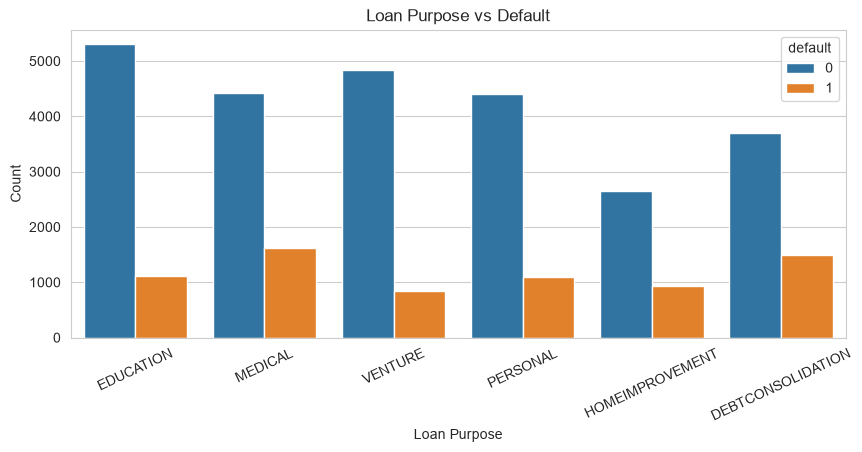

In [29]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='loan_purpose', hue='default')
plt.title('Loan Purpose vs Default')
plt.xlabel('Loan Purpose')
plt.ylabel('Count')
plt.xticks(rotation=25)
plt.show()

###  Previous Default on File vs Current Default

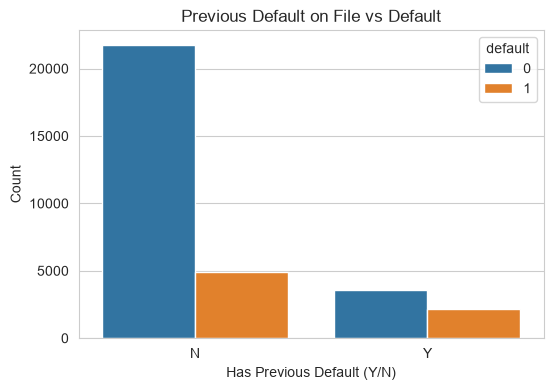

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='previous_default', hue='default')
plt.title('Previous Default on File vs Default')
plt.xlabel('Has Previous Default (Y/N)')
plt.ylabel('Count')
plt.show()

###  Applicant Age Distribution

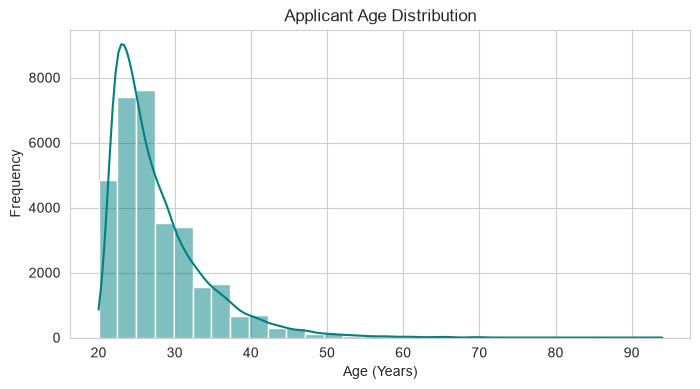

In [31]:
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=30, kde=True, color='teal')
plt.title('Applicant Age Distribution')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.show()

###  Applicant Income Distribution

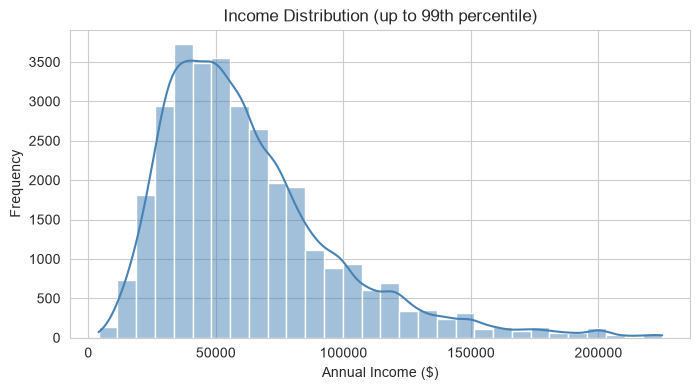

In [ ]:
plt.figure(figsize=(8, 4))
income_99 = df[df['income'] <= df['income'].quantile(0.99)]['income']
sns.histplot(income_99, bins=30, kde=True, color='steelblue')
plt.title('Income Distribution (up to 99th percentile)')
plt.xlabel('Annual Income ($)')
plt.ylabel('Frequency')
plt.show()

###  Loan Amount Distribution

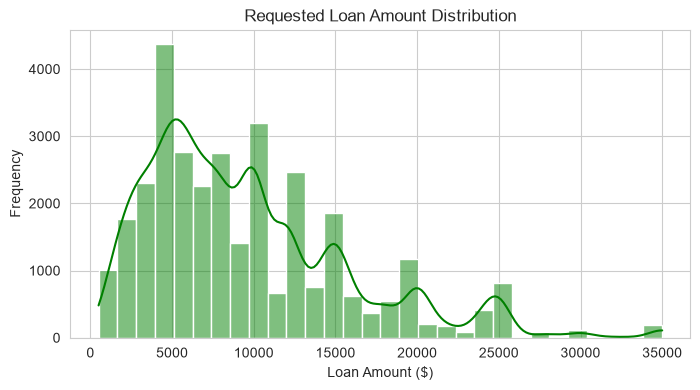

In [33]:
plt.figure(figsize=(8, 4))
sns.histplot(df['loan_amount'], bins=30, kde=True, color='green')
plt.title('Requested Loan Amount Distribution')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Frequency')
plt.show()

###  Interest Rate Distribution

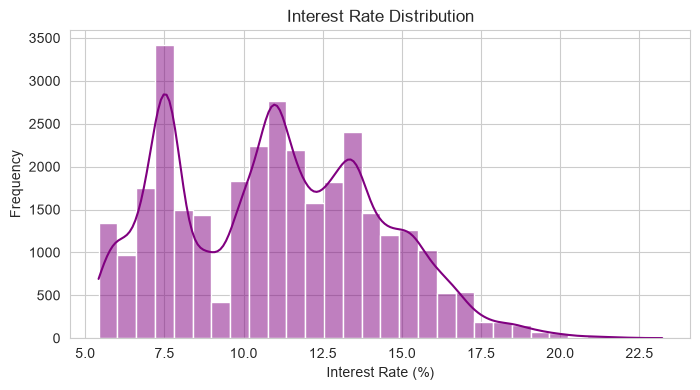

In [34]:
plt.figure(figsize=(8, 4))
sns.histplot(df['interest_rate'], bins=30, kde=True, color='purple')
plt.title('Interest Rate Distribution')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Frequency')
plt.show()

###  Employment Years Distribution

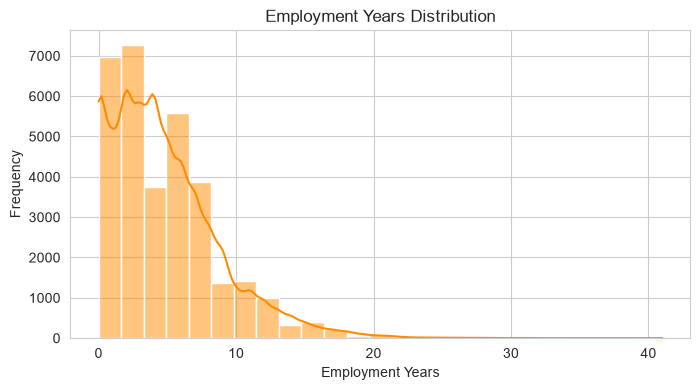

In [35]:
plt.figure(figsize=(8, 4))
sns.histplot(df['employment_years'], bins=25, kde=True, color='darkorange')
plt.title('Employment Years Distribution')
plt.xlabel('Employment Years')
plt.ylabel('Frequency')
plt.show()

###  Loan-to-Income Ratio Distribution

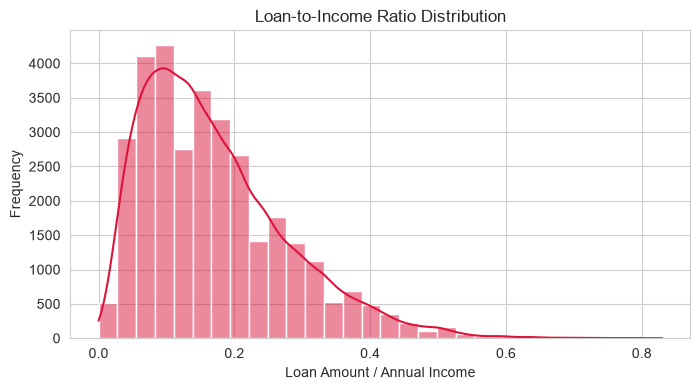

In [36]:
plt.figure(figsize=(8, 4))
sns.histplot(df['loan_income_ratio'], bins=30, kde=True, color='crimson')
plt.title('Loan-to-Income Ratio Distribution')
plt.xlabel('Loan Amount / Annual Income')
plt.ylabel('Frequency')
plt.show()

###  Loan-to-Income Ratio vs Default (Boxplot)

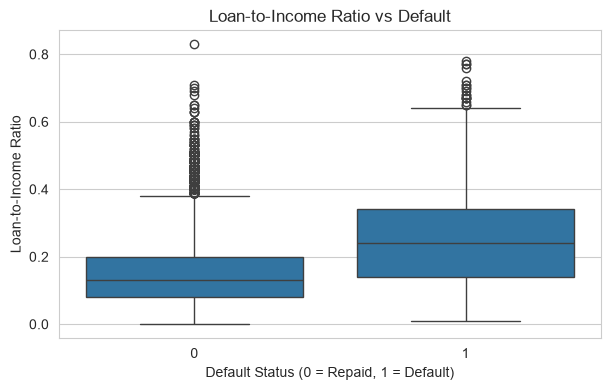

In [37]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='default', y='loan_income_ratio')
plt.title('Loan-to-Income Ratio vs Default')
plt.xlabel('Default Status (0 = Repaid, 1 = Default)')
plt.ylabel('Loan-to-Income Ratio')
plt.show()

###  Interest Rate vs Default (Boxplot)

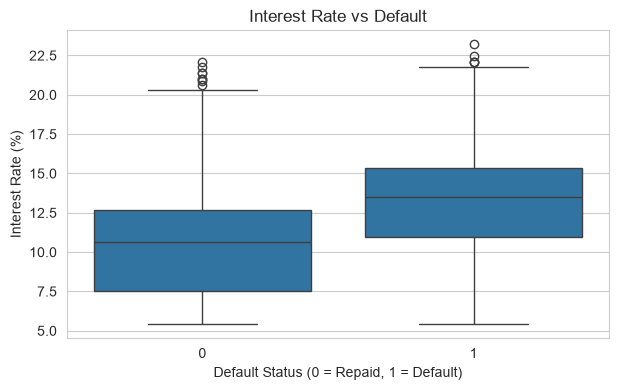

In [38]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='default', y='interest_rate')
plt.title('Interest Rate vs Default')
plt.xlabel('Default Status (0 = Repaid, 1 = Default)')
plt.ylabel('Interest Rate (%)')
plt.show()

### Applicant Income vs Default (Log Scale Boxplot)

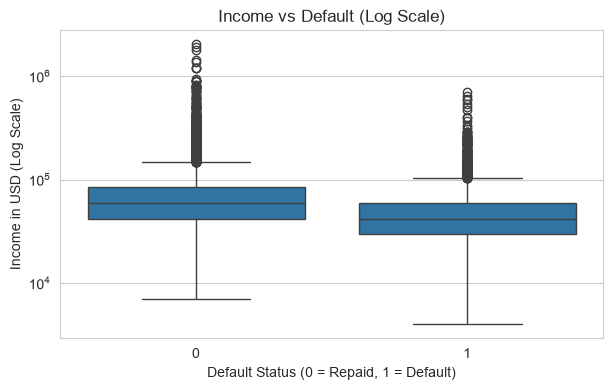

In [39]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='default', y='income')
plt.yscale('log')
plt.title('Income vs Default (Log Scale)')
plt.xlabel('Default Status (0 = Repaid, 1 = Default)')
plt.ylabel('Income in USD (Log Scale)')
plt.show()

### Loan Amount vs Default (Boxplot)

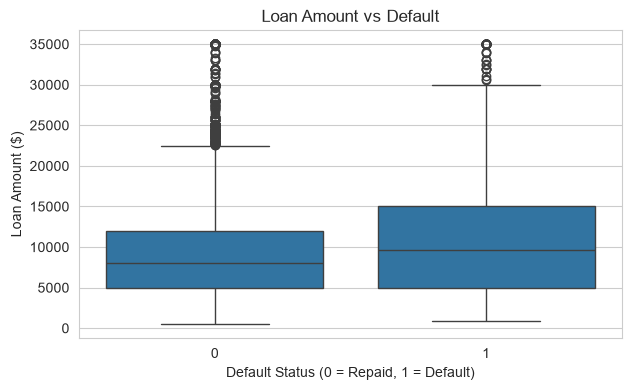

In [40]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='default', y='loan_amount')
plt.title('Loan Amount vs Default')
plt.xlabel('Default Status (0 = Repaid, 1 = Default)')
plt.ylabel('Loan Amount ($)')
plt.show()

###  Employment Years vs Default (Boxplot)

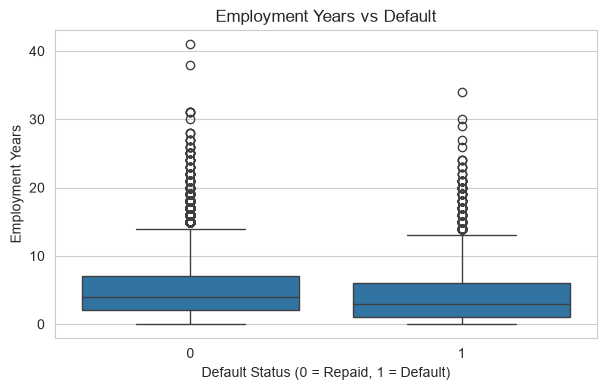

In [41]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='default', y='employment_years')
plt.title('Employment Years vs Default')
plt.xlabel('Default Status (0 = Repaid, 1 = Default)')
plt.ylabel('Employment Years')
plt.show()

###  Correlation Matrix Heatmap

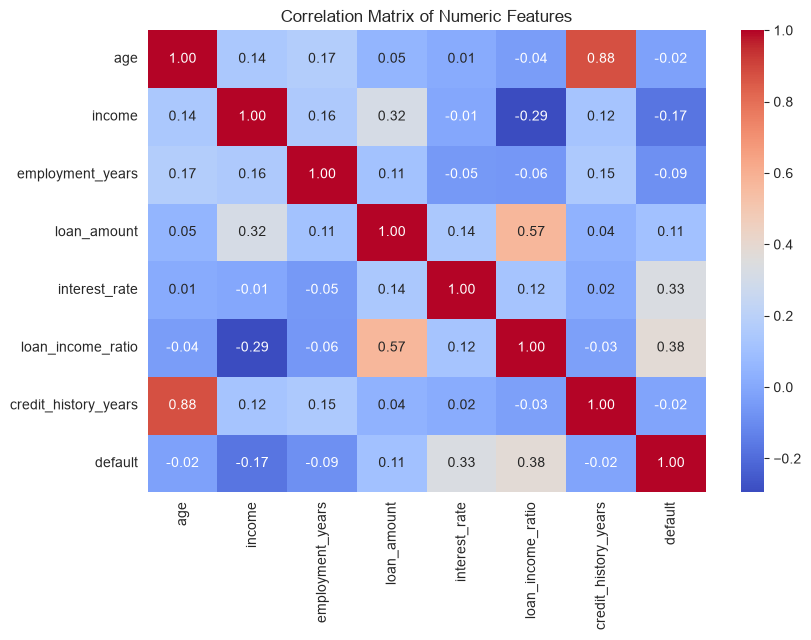

In [42]:
numeric_cols = ['age', 'income', 'employment_years', 'loan_amount', 'interest_rate', 'loan_income_ratio', 'credit_history_years', 'default']

plt.figure(figsize=(9, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

###  Income vs Loan Amount Scatter Plot (Colored by Default)

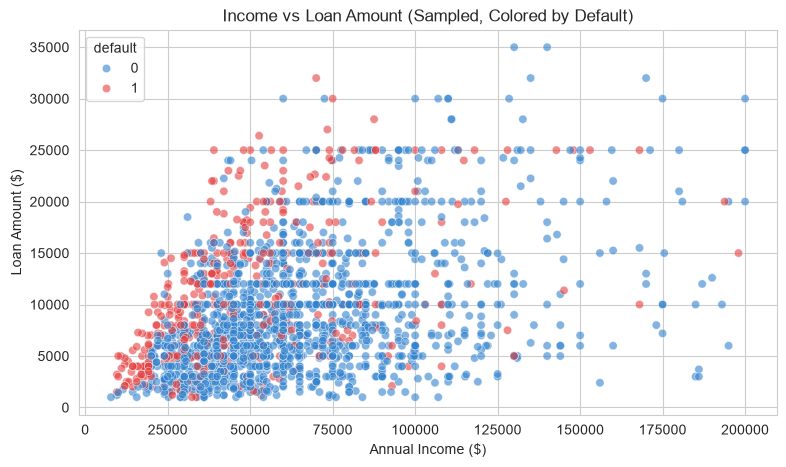

In [ ]:
plt.figure(figsize=(9, 5))
sample_df = df[df['income'] <= 200000].sample(n=min(2000, len(df)), random_state=42)

sns.scatterplot(
    data=sample_df,
    x='income',
    y='loan_amount',
    hue='default',
    palette={0: '#3182CE', 1: '#E53E3E'},
    alpha=0.6
)
plt.title('Income vs Loan Amount (Sampled, Colored by Default)')
plt.xlabel('Annual Income ($)')
plt.ylabel('Loan Amount ($)')
plt.show()

###  Default Rate by Loan-to-Income (LTI) Bins

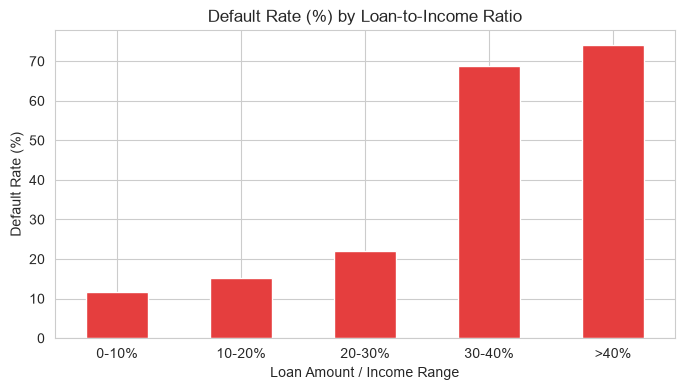

In [ ]:
df['lti_bin'] = pd.cut(
    df['loan_income_ratio'],
    bins=[0.0, 0.1, 0.2, 0.3, 0.4, 1.0],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '>40%']
)

lti_default_rate = df.groupby('lti_bin', observed=True)['default'].mean() * 100

plt.figure(figsize=(8, 4))
lti_default_rate.plot(kind='bar', color='#E53E3E')
plt.title('Default Rate (%) by Loan-to-Income Ratio')
plt.xlabel('Loan Amount / Income Range')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()